In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Arial
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12

In [2]:
data0 = pd.read_csv('nash_equilibrium_results.csv')
data1 = pd.read_csv('demo_case_full_solution.csv')

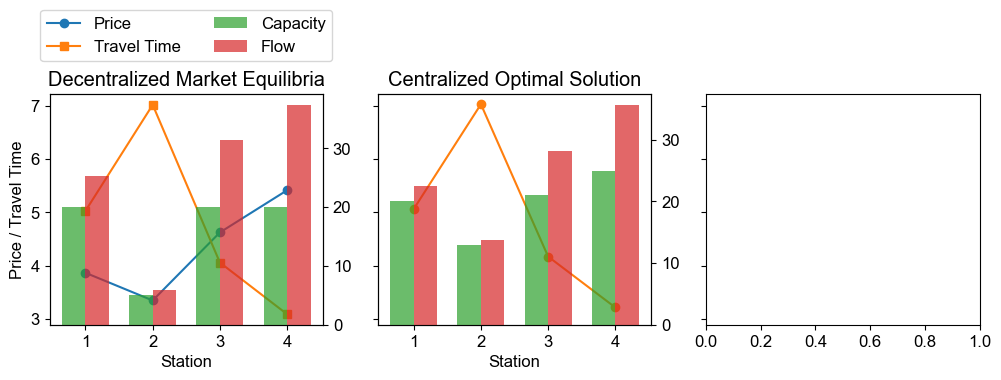

In [5]:
# Suppose you already have your data list
df = pd.DataFrame(data0)

# Set station IDs as x-axis
stations = df["Station"]

fig, ax = plt.subplots(1, 3, figsize=(12, 3), dpi=100, sharey=True)

# --- Line plot: Price and Travel Time ---
ax[0].plot(stations, df["Price"], marker="o", label="Price", color="tab:blue")
ax[0].plot(stations, df["Travel Time"], marker="s", label="Travel Time", color="tab:orange")
ax[0].set_xlabel("Station")
ax[0].set_ylabel("Price / Travel Time")

# --- Bar plot: Capacity and Flow (clustered) ---
ax2 = ax[0].twinx()  # secondary y-axis
bar_width = 0.35
x = range(1, len(stations)+1)

ax2.bar([i - bar_width/2 for i in x], df["Capacity"], 
        width=bar_width, label="Capacity", color="tab:green", alpha=0.7)
ax2.bar([i + bar_width/2 for i in x], df["Flow"], 
        width=bar_width, label="Flow", color="tab:red", alpha=0.7)


# --- Legends (merged into one box) ---
lines_labels = [ax.get_legend_handles_labels() for ax in [ax[0], ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax[0].legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, 1.4),
           ncol=2, frameon=True, fancybox=True)


# --- Tidy up ---
ax[0].set_xticks(x)
ax[0].set_xticklabels(stations)

# global result from demo_case_full_solution.csv, no price but have all other elements
df1 = pd.DataFrame(data1)

# --- Line plot: Global Price and Travel Time ---
ax[1].plot(df1["Station"], df1["TravelTime"], 
           marker="o", label="Global Travel Time", color="tab:orange")
ax[1].set_xlabel("Station")

ax12 = ax[1].twinx()  # secondary y-axis
ax12.bar([i - bar_width/2 for i in x], df1["Capacity"], 
        width=bar_width, label="Capacity", color="tab:green", alpha=0.7)
ax12.bar([i + bar_width/2 for i in x], df1["Flow"], 
        width=bar_width, label="Flow", color="tab:red", alpha=0.7)


# ax22.set_ylabel("Capacity / Flow")


ax[0].set_title("Decentralized Market Equilibria")
ax[1].set_title("Centralized Optimal Solution")

plt.savefig("nash_equilibrium_plot.pdf", bbox_inches='tight', dpi=300)